# 1. Matches: one matrix, played many times

**Goal.** Build a game from its payoff matrix, let two strategies play it repeatedly, read the result, and write a first strategy.

In [ ]:
#if axelrod is not installed on colab, install it with
#!pip install axelrod

In [ ]:
# !!!! ONLY ON COLAB !!!!
import sys
import os
from google.colab import drive

#give access to your personal Google Drive (check the authorization, ...)
drive.mount('/content/drive')


# 2. Add the exact path where you put the jupyter books and myNashTools.py
# (Example : if it is in folder the "Colab Notebooks/Axelrod-Book" on your Drive)
my_folder = '/content/drive/MyDrive/Colab Notebooks/Axelrod-Book'
if my_folder not in sys.path:
    sys.path.insert(0, my_folder)


if os.path.exists(my_folder):
    print(f"✅ the folder exists !")
    fichiers = os.listdir(my_folder)
    print("Content of the folder :", fichiers)
    
    # On force l'insertion au tout début du path
    if my_folder not in sys.path:
        sys.path.insert(0, my_folder)
        
else:
    print(f"❌ folder does not exist at this path. Verify the spelling or the space.")


In [ ]:
import axelrod as axl
import numpy as np
import matplotlib.pyplot as plt
from myIGTools import show_game, plot_match

C, D = axl.Action.C, axl.Action.D

----

## 1.1 The payoff matrix

`axl.Game(r, s, t, p)` builds a **symmetric 2×2 game** with actions `C` and `D`:

| row \ column | C | D |
|---|---|---|
| **C** | (R, R) | (S, T) |
| **D** | (T, S) | (P, P) |

With $T > R > P > S$ it is a **prisoner's dilemma**.  
The default values are Axelrod's: $R=3, S=0, T=5, P=1$.

In [3]:
pd = axl.Game()                 # same as axl.Game(r=3, s=0, t=5, p=1)
show_game(pd, title="Prisoner's dilemma")
print("R, P, S, T =", pd.RPST())
print("score of (C, D):", pd.score((C, D)))

Prisoner's dilemma
       C         D     
C    (3, 3)    (0, 5)  
D    (5, 0)    (1, 1)  

R, P, S, T = (3, 1, 0, 5)
score of (C, D): (0, 5)


**Exercise 1** *(≈ 6 lines)*. 
  - Build the two games below with `axl.Game`.
  - Display them with `show_game`,
  - Then check with `RPST()` which of the three games (`pd`, `stag`, `chicken`) satisfies $T > R > P > S$.

- **Stag hunt**: (C,C) → 4, (C,D) → 0, (D,C) → 3, (D,D) → 3.   
Hunting the stag (C) only pays if both do it.
- **Chicken**: (C,C) → 3, (C,D) → 1, (D,C) → 5, (D,D) → 0.   
Going straight (D) pays only if the other swerves.

In [ ]:
# Question 1: your code here

Stag hunt
       C         D     
C    (4, 4)    (0, 3)  
D    (3, 0)    (3, 3)  

Chicken
       C         D     
C    (3, 3)    (1, 5)  
D    (5, 1)    (0, 0)  

PD         prisoner's dilemma: t=5 > r=3 > p=1 > s=0 ? :  True
Stag hunt  prisoner's dilemma: t=3 > r=4 > p=3 > s=0 ? :  False
Chicken    prisoner's dilemma: t=5 > r=3 > p=0 > s=1 ? :  False


Only the first game is a dilemma: 
- in the stag hunt, cooperating is the best answer to cooperation ($R > T$); 
- in chicken, cooperating is the best answer to defection ($S > P$).

---

## 1.2 A match

In a repeated game, a **strategy** is a rule that chooses `C` or `D` from the history of the match. Some classic strategies:

| Strategy | Rule |
|---|---|
| `axl.Cooperator()` | always C |
| `axl.Defector()` | always D |
| `axl.TitForTat()` | C first, then copies the opponent's last move |
| `axl.Grudger()` | C until the opponent defects once, then D forever |
| `axl.Alternator()` | C, D, C, D, … |
| `axl.WinStayLoseShift()` | keeps its move after a good payoff (R or T), changes after a bad one (S or P) |
| `axl.Random()` | C or D with probability 1/2 |

`axl.Match` makes two strategies play a given number of turns.

In [ ]:
#match set up
match = axl.Match((axl.TitForTat(), axl.Defector()), turns=10, game=pd)
#lets play the match
match.play()
#history of the actions of the players
print(match.sparklines(c_symbol="C", d_symbol="D"))
#scores of the players
print("total scores :", match.final_score())
print("per turn     :", match.final_score_per_turn())
print("winner       :", match.winner())

CDDDDDDDDD
DDDDDDDDDD
total scores : (9, 14)
per turn     : (0.9, 1.4)
winner       : Defector


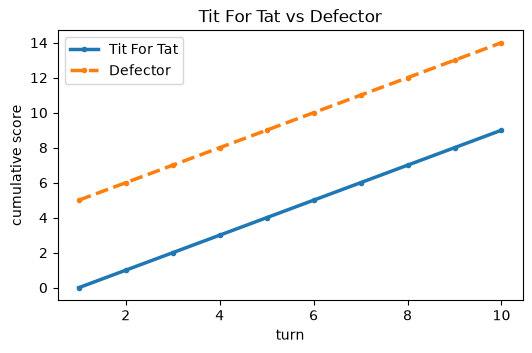

In [9]:
#little tools to plot the match
plot_match(match)
plt.show()

**Reading.** 
  - Tit For Tat is fooled once, then defects as well: it loses the match (9 against 14), but by a small margin. 
  - Tit For Tat can never beat its opponent in a single match; its strength will appear in tournaments (exercise 2).

**Question 2** *(≈ 5 lines)*. 
- Make `TitForTat`, `Grudger` and `WinStayLoseShift` each play 12 turns against `Alternator`. 
- For each match, print the moves and the final scores. Which strategy earns the most against Alternator?

In [7]:
# Exercise 2: your code here

CCDCDCDCDCDC
CDCDCDCDCDCD
Tit For Tat -> (28, 33) 

CCDDDDDDDDDD
CDCDCDCDCDCD
Grudger -> (33, 13) 

CCDDCCDDCCDD
CDCDCDCDCDCD
Win-Stay Lose-Shift -> (27, 27) 



'Grudger' stops being exploited after the first D and then gets $T=5$ every other turn.  
'Tit For Tat' ends up "out of phase" with 'Alternator', and 'Win-Stay Lose-Shift' gets trapped in a cycle.

---

## 1.3 Same strategies, another matrix

The strategies only see `C` and `D`: they do not know the payoffs.  
Changing the matrix therefore changes the scores, not the moves.

**Question 3** *(≈ 7 lines)*. 
- For each of the three games (`pd`, `stag`, `chicken`), play `TitForTat` against `Defector` for 15 turns and draw the cumulative scores side by side. 
- Use `fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))` and `plot_match(m, ax=ax, title=...)`. 
- Against Tit For Tat, in which game is defecting a bad idea?

In [9]:
# Exercise 3: your code here

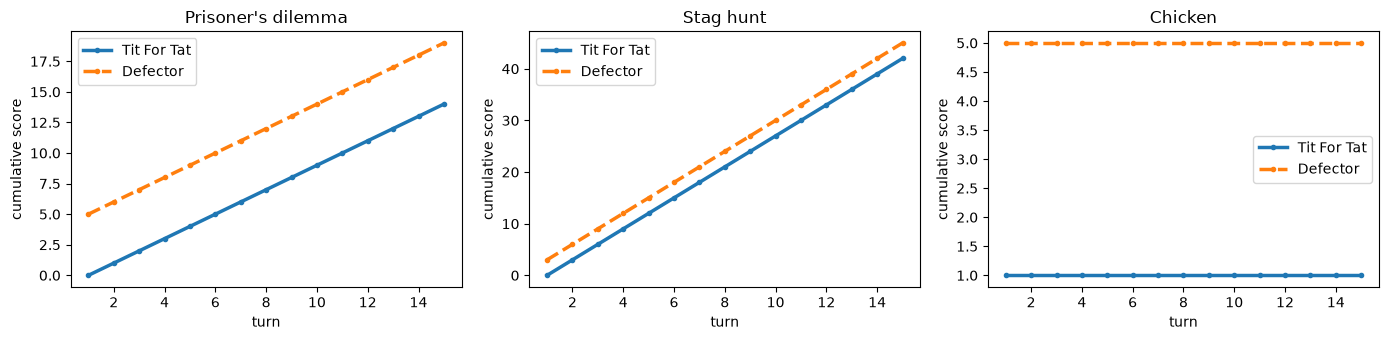

In [12]:
games = {"Prisoner's dilemma": pd, "Stag hunt": stag, "Chicken": chicken}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (name, g) in zip(axes, games.items()):
    m = axl.Match((axl.TitForTat(), axl.Defector()), turns=15, game=g)
    m.play()
    plot_match(m, ax=ax, title=name)
plt.tight_layout(); plt.show()

In **chicken**, mutual defection gives $P=0$: after the first turn, the defector earns nothing, while two cooperators would have earned 3 per turn. In the **stag hunt**, defection is "safe" ($P = T = 3$) but less profitable than mutual cooperation ($R=4$).


---

## 1.4 Writing your own strategy

A strategy is a class that inherits from `axl.Player` and defines `strategy(self, opponent)`.   
`opponent.history` is the list of the opponent's past moves.  
Here is Tit For Tat, rewritten:

In [13]:
class Copycat(axl.Player):
    name = "Copycat"

    def strategy(self, opponent):
        if len(opponent.history) == 0:
            return C                       # first turn: cooperate
        return opponent.history[-1]        # then copy the opponent's last move

m = axl.Match((Copycat(), axl.Alternator()), turns=8)
m.play()
print(m.sparklines(c_symbol="C", d_symbol="D"))

CCDCDCDC
CDCDCDCD


**Question 4** *(≈ 10 lines)*. 
- Write a class `MyTitForTwoTats`: it cooperates, except when the opponent **defected on both of the last two turns**. 
- Check that it plays exactly like `axl.TitFor2Tats()` against `axl.Random()` over 20 turns (use the same `seed=3` for both matches).

*Hint:* `opponent.history[-2:]` gives the last two moves, as a list.

In [12]:
# Exercise 4: your code here

My Tit For Two Tats    CCCCCCDCCCDDDDCCCCCC
Tit For 2 Tats         CCCCCCDCCCDDDDCCCCCC


---

## 1.5 Going further: non-symmetric matrices

`axl.AsymmetricGame(A, B)` accepts any pair of 2×2 matrices (A for the row player, B for the column player).  
The actions are still called `C` (first row/column) and `D` (second).  
Example: a **battle of the sexes**, where C = *opera* and D = *football*.

In [15]:
A = np.array([[2, 0], [0, 1]])     # the row player prefers the opera
B = np.array([[1, 0], [0, 2]])     # the column player prefers football
bos = axl.AsymmetricGame(A, B)
show_game(bos, actions=("opera", "football"), title="Battle of the sexes")

m = axl.Match((axl.Cooperator(), axl.TitForTat()), turns=6, game=bos)
m.play(); print(m.final_score())

Battle of the sexes
            opera    football 
   opera    (2, 1)    (0, 0)  
football    (0, 0)    (1, 2)  

(12, 6)


- Cooperator always goes to the opera and Tit For Tat follows: they coordinate on the row player's favourite outcome. 
- Try other pairs of strategies: who gets to choose the evening?

---

## Summary

| To… | write |
|---|---|
| define a symmetric 2×2 game | `axl.Game(r=…, s=…, t=…, p=…)` |
| define any 2×2 bimatrix game | `axl.AsymmetricGame(A, B)` |
| play a match | `m = axl.Match((p1, p2), turns=…, game=…)` then `m.play()` |
| read the result | `m.final_score()`, `m.final_score_per_turn()`, `m.winner()`, `m.sparklines()` |
| write a strategy | a subclass of `axl.Player` with a `strategy(self, opponent)` method |